# Notebook 9 – Konfidenzintervalle

## 1. Einführung
- Definition: Ein Konfidenzintervall (CI) ist ein Bereich, der mit einer bestimmten Wahrscheinlichkeit den wahren Parameterwert enthält.
- Intuition: Ein 95 %-CI bedeutet, dass bei wiederholten Stichproben 95 % der berechneten Intervalle den wahren Wert enthalten würden.
- Beispielhafte Anwendung: CI für den Mittelwert einer Normalverteilung.

## 2. Mathematische Grundlagen
- CI für den Mittelwert (bekannte Varianz):
$$
\mu \in \left[ \bar{x} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \;\bar{x} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right]
$$

- CI für den Mittelwert (unkannte Varianz):
$$
\mu \in \left[ \bar{x} - t_{\alpha/2, n-1} \frac{s}{\sqrt{n}}, \;\bar{x} + t_{\alpha/2, n-1} \frac{s}{\sqrt{n}} \right]
$$

- CI für Anteile:
$$
p \in \left[ \hat{p} - z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}, \;\hat{p} + z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \right]
$$

- CI für Varianz:
$$
\sigma^2 \in \left[ \frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}}, \;\frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}} \right]
$$

## 3. Einfluss der Stichprobengröße und Unsicherheit
- Breite des CI nimmt mit größerer Stichprobe ab.
- Breite des CI reflektiert die Unsicherheit der Schätzung.
- Visualisierung von CI für verschiedene Stichprobengrößen.

## 4. Bootstrapping
- Prinzip: Wiederholtes Ziehen von Stichproben mit Zurücklegen, um CIs zu schätzen.
- Vorteile: Keine Annahme über die Verteilung der Daten nötig.
- Anwendung: CI für den Mittelwert mittels Bootstrapping.

## 5. Anwendung in der Modellbewertung
- CI für Modellmetriken wie Genauigkeit, Fehlermaße, F1-Score.
- Beispiel: 95 %-CI für die Genauigkeit eines Klassifikators.
- Interpretation: Bereich, in dem die wahre Modellleistung mit bestimmter Wahrscheinlichkeit liegt.

## 6. Erweiterte Themen
- Simultane Konfidenzintervalle für mehrere Parameter.
- Konfidenzintervalle in der Zeitreihenanalyse.
- CI für Deep-Learning-Modelle zur Quantifizierung von Unsicherheit.

## 7. Praktische Übungen
- Interaktive Widgets zur Visualisierung von CIs.
- Simulationen zur Veranschaulichung von Stichprobengröße und Unsicherheit.
- Vergleich traditioneller und moderner CI-Schätzmethoden.


# 1. Einführung in Konfidenzintervalle

## 1.1 Was ist ein Konfidenzintervall?

Ein **Konfidenzintervall (CI)** ist ein Bereich von Werten, der mit einer bestimmten Wahrscheinlichkeit den **wahren Wert eines Parameters** (z. B. Mittelwert, Varianz, Anteil) einer Population enthält.

- In der Statistik wissen wir in der Regel **nie den wahren Parameter einer Population**. Wir können nur auf Basis einer Stichprobe schätzen.  
- Das CI gibt an, **in welchem Bereich dieser wahre Wert mit einer bestimmten Wahrscheinlichkeit liegt**, wenn wir den Prozess der Stichprobenziehung wiederholen würden.

**Wichtiger Punkt zur Interpretation:**  
Ein 95 %-CI bedeutet **nicht**, dass die Wahrscheinlichkeit 95 % beträgt, dass der wahre Parameter innerhalb des Intervalls liegt.  
Richtig: *Wenn wir unendlich viele Stichproben derselben Größe ziehen würden, würden 95 % der daraus berechneten Intervalle den wahren Wert enthalten.*

---

## 1.2 Intuition

- CIs quantifizieren die **Unsicherheit** unserer Schätzung.  
- Je größer die Stichprobe, desto **enger** das CI → höhere Sicherheit.  
- Breites CI → große Unsicherheit (kleine Stichprobe oder große Varianz)  
- Schmaleres CI → kleine Unsicherheit (große Stichprobe oder kleine Varianz)

---

## 1.3 Beispiele

1. **Mittelwert einer Normalverteilung**  
   - Stichprobe: 30 Personen  
   - Stichprobenmittelwert: $\bar{x} = 172$ cm  
   - Standardabweichung bekannt: $\sigma = 8$ cm  
   - 95 %-CI:  
   $$
   \bar{x} \pm z_{0.975} \frac{\sigma}{\sqrt{n}}
   $$  
   Interpretation: Wenn wir viele Stichproben von 30 Personen ziehen, enthalten 95 % der berechneten Intervalle den wahren Mittelwert aller Studenten.

2. **Anteile / Wahrscheinlichkeiten**  
   - Stichprobe: 100 Kunden, 60 kaufen ein Produkt → $\hat{p} = 0.6$  
   - 95 %-CI:  
   $$
   \hat{p} \pm z_{0.975} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
   $$  
   Interpretation: Wir quantifizieren, in welchem Bereich der wahre Anteil $p$ liegt.

3. **Varianz**  
   - Beispiel: Fehlermaße eines ML-Modells (z. B. MSE)  
   - CI für die Varianz:  
   $$
   \sigma^2 \in \left[ \frac{(n-1)s^2}{\chi^2_{0.975,n-1}}, \frac{(n-1)s^2}{\chi^2_{0.025,n-1}} \right]
   $$  
   Interpretation: Wir sehen, wie stabil die Schätzung der Varianz ist.

---

## 1.4 Warum sind Konfidenzintervalle wichtig?

1. **Unsicherheit quantifizieren:**  
   Punktwerte (Mittelwert, Modellgenauigkeit) allein sagen nichts über die **Zuverlässigkeit** der Schätzung aus.

2. **Vergleich von Modellen oder Gruppen:**  
   - Überlappen die CIs nicht stark, kann man mit höherer Sicherheit sagen, dass ein Unterschied existiert.  
   - ML-Anwendung: Vergleich von Klassifikatoren (Accuracy, F1-Score, AUC).

3. **Entscheidungsfindung:**  
   - CIs helfen, Risiken abzuschätzen.  
   - Beispiel: A/B-Test → CI für Conversion-Rate zeigt, ob eine Variante wirklich besser ist.

---

## 1.5 Praktischer Bezug zu Machine Learning

- **Modellevaluation:** CIs für Accuracy, Recall, F1-Score oder ROC-AUC helfen, **die Stabilität von Modellergebnissen** zu interpretieren.  
- **Hyperparameter-Tuning:** CIs zeigen, ob Unterschiede zwischen Parametereinstellungen **signifikant** sind.  
- **Probabilistische Vorhersagen:** In Bayesianischen Modellen liefern CIs oder Credible Intervals direkte Unsicherheitsabschätzungen.

---


In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, IntSlider, FloatSlider, FloatText, VBox, Button, Output

# Ausgabe-Widget
out = Output()
state = {'x': None}

def plot_ci(n=10, mu=5.0, sigma=2.0, conf_level=0.95, repeat=False):
    if repeat or state['x'] is None:
        state['x'] = np.random.normal(mu, sigma, n)
    x = state['x']
    x_bar = np.mean(x)
    
    alpha = 1 - conf_level
    z = norm.ppf(1 - alpha/2)
    ci_lower = x_bar - z * sigma/np.sqrt(n)
    ci_upper = x_bar + z * sigma/np.sqrt(n)
    
    # Plot
    plt.figure(figsize=(10, 2))
    plt.errorbar(x_bar, 0, xerr=[[x_bar - ci_lower], [ci_upper - x_bar]], fmt='o', color='blue', label=f'{int(conf_level*100)}%-CI')
    plt.scatter(x, np.zeros_like(x)-0.05, color='black', marker='x', label='Stichprobe')
    plt.axvline(mu, color='red', linestyle='--', label='Wahrer μ')
    plt.yticks([])
    plt.xlabel('μ')
    plt.title(f'Konfidenzintervall für μ (n={n}, σ={sigma}, Mittelwert der Stichprobe={x_bar:.2f})')
    plt.legend()
    plt.show()
    
    with out:
        out.clear_output(wait=True)
        print(f"Stichprobenmittelwert: {x_bar:.2f}")
        print(f"{int(conf_level*100)}%-CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
        print("Beobachte, wie das Intervall enger wird, wenn n steigt oder σ kleiner wird.")

# Button zum Ziehen einer neuen Stichprobe
repeat_button = Button(description="Neue Stichprobe ziehen", button_style='info')
repeat_button.on_click(lambda b: plot_ci(repeat=True))

# Interaktives Widget
interact(
    plot_ci,
    n=IntSlider(min=2, max=100, step=1, value=10, description="Stichprobengröße"),
    mu=FloatSlider(min=-10, max=10, step=0.1, value=5, description="Wahrer μ"),
    sigma=FloatSlider(min=0.1, max=5, step=0.1, value=2, description="σ"),
    conf_level=FloatSlider(min=0.8, max=0.99, step=0.01, value=0.95, description="Konfidenzniveau")
)

VBox([repeat_button, out])


interactive(children=(IntSlider(value=10, description='Stichprobengröße', min=2), FloatSlider(value=5.0, descr…

# Interaktiver Plot: Konfidenzintervall für den Mittelwert

Dieser interaktive Plot zeigt das **Konfidenzintervall (CI)** für den Mittelwert einer Normalverteilung:

- **Schwarze Kreuze**: Stichprobenwerte  
- **Blauer Punkt + Fehlerbalken**: Stichprobenmittelwert ± CI  
- **Rote Linie**: Wahrer Mittelwert μ  

### Bedienung:
- **Stichprobengröße (n)**: Einfluss auf die Breite des Intervalls  
- **σ (Standardabweichung)**: Größere σ → breiteres CI  
- **Konfidenzniveau**: Höheres Niveau → breiteres CI  
- **Neue Stichprobe ziehen**: Zeigt die Variabilität zwischen Stichproben

So kannst du interaktiv **sehen, wie die Stichprobengröße, Varianz und das Konfidenzniveau die Unsicherheit der Schätzung beeinflussen**.


# 2. Mathematische Grundlagen der Konfidenzintervalle

Konfidenzintervalle (CIs) geben an, in welchem Bereich der **wahre Parameter** einer Population mit einer bestimmten Wahrscheinlichkeit liegt. Sie quantifizieren die **Unsicherheit** der Schätzung.

---

## 2.1 CI für den Mittelwert (σ bekannt)

Für eine Normalverteilung mit bekannter Populationsstandardabweichung $\sigma$ gilt:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

- $\bar{x}$: Stichprobenmittelwert  
- $n$: Stichprobengröße  
- $x_i$: einzelne Stichprobenwerte

Der Mittelwert $\bar{x}$ folgt der Verteilung:

$$
\bar{x} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

Ein $100(1-\alpha)\%$-Konfidenzintervall für den Mittelwert:

$$
CI = \bar{x} \pm z_{1-\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}
$$

- $z_{1-\alpha/2}$: Quantil der Standardnormalverteilung  
- Breite des Intervalls: $\propto \frac{\sigma}{\sqrt{n}}$ → größere Stichprobe → schmaleres CI

**Beispielrechnung:**

- n = 25, $\bar{x} = 100$, σ = 15, 95 %-CI  
- z_{0.975} ≈ 1.96  
- Standardfehler: $SE = \sigma / \sqrt{n} = 15 / \sqrt{25} = 3$  
- CI = 100 ± 1.96·3 = [94.12, 105.88]

**Intuition:**  
- Mehr Daten → kleinerer Standardfehler → engeres CI  
- Weniger Daten oder größere σ → breiteres CI → höhere Unsicherheit

---

## 2.2 CI für den Mittelwert (σ unbekannt)

Wenn die Populationsstandardabweichung **nicht bekannt**:

$$
CI = \bar{x} \pm t_{n-1, 1-\alpha/2} \cdot \frac{s}{\sqrt{n}}
$$

- $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2}$: Stichprobenstandardabweichung  
- $t_{n-1, 1-\alpha/2}$: Quantil der t-Verteilung mit $n-1$ Freiheitsgraden  
- Standardfehler: $SE = s/\sqrt{n}$

### Warum die t-Verteilung?

- Bei **kleinen Stichproben** ist unsere Schätzung der Standardabweichung $s$ unsicher.  
- Die t-Verteilung ist **breiter** als die Standardnormalverteilung (z-Verteilung).  
  → Das Konfidenzintervall wird **größer**, um diese zusätzliche Unsicherheit abzudecken.  

**Formelzeichen:**

| Symbol | Bedeutung |
|--------|-----------|
| $s$ | Stichprobenstandardabweichung |
| $t_{n-1, 1-\alpha/2}$ | Quantil der t-Verteilung mit $n-1$ Freiheitsgraden |
| $z_{1-\alpha/2}$ | Quantil der Standardnormalverteilung $\mathcal{N}(0,1)$ |

- **$z$**: Quantil der Standardnormalverteilung $\mathcal{N}(0,1)$, wird verwendet, wenn σ bekannt oder n groß ist.  

---

#### Intuition zum Einfluss der Stichprobengröße

- **Kleine Stichprobe (n klein)** → unsicherer Mittelwert → breite t-Verteilung → breiteres CI  
- **Große Stichprobe (n steigt)** → s nähert sich σ → t-Verteilung wird **schmaler**  
  - Die t-Verteilung nähert sich der **Normalverteilung** an  
  - CI wird enger, fast so wie bei Verwendung von $z$  

**Anschaulich:**

- Kleine n → „unsicherer Mittelwert“ → breites CI  
- Große n → „sicherer Mittelwert“ → CI wird enger, fast wie bei bekannter σ


**Beispielrechnung:**

- n = 5, x = [4.8, 5.2, 5.5, 4.9, 5.1], 95 %-CI  
- $\bar{x} = 5.10$  
- $s = 0.308$  
- t_{4,0.975} ≈ 2.776  
- SE = 0.308 / √5 ≈ 0.138  
- CI = 5.10 ± 2.776·0.138 ≈ [4.717, 5.483]

**Intuition:**  
- Kleine Stichprobe → breiteres CI  
- Größere Stichprobe → engeres CI → t ≈ z

---

## 2.3 CI für Anteile / Wahrscheinlichkeiten

Für einen Anteil $p$ aus einer Binomialverteilung:

$$
\hat{p} = \frac{k}{n} \quad \text{mit } k \text{ Erfolgen in } n \text{ Versuchen}
$$

Das 100(1-$\alpha$)\%-Konfidenzintervall (approximativ normal) ist:

$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

---

### Unterschied zum Mittelwert-CI

- Im Mittelwert-CI geht es um **kontinuierliche Daten** (z. B. Größe, Gewicht, Messwerte)  
- Bei Anteilen/Probabilities handelt es sich um **binäre Ereignisse** (Erfolg/Misserfolg, 1/0)  
- Formel: Standardfehler basiert auf $\hat{p}(1-\hat{p})$ statt auf $\sigma^2$  
- Für kleine Stichproben oder extreme Anteile sind approximative Formeln ungenau → Wilson- oder Clopper-Pearson-Intervalle besser

---




### Einschränkungen der normalen Approximation

- Die Standardformel setzt voraus, dass **n groß genug** ist, sodass die Verteilung von $\hat{p}$ näherungsweise normal ist  
- Für **kleine Stichproben** oder wenn $\hat{p}$ **sehr nahe 0 oder 1** liegt, ist die Normalapproximation **ungenau**  
  - Beispiel: n=10, k=1 → Standardfehler berechnet aus $\hat{p}(1-\hat{p})/n$ ist klein, CI kann sogar unter 0 oder über 1 hinausgehen → unrealistisch  

---

### Alternative Intervalle

1. **Wilson-Interval**  
   - Modifiziert die Standardformel, um bessere Abdeckung bei kleinen n zu garantieren  
   - CI bleibt innerhalb [0,1], nicht symmetrisch um $\hat{p}$

2. **Clopper-Pearson-Interval** (exakte Binomialintervalle)  
   - Verwendet die **exakte Binomialverteilung**, nicht Normalapproximation  
   - Garantiert, dass der wahre Anteil mit mindestens (1-α) Wahrscheinlichkeit im Intervall liegt  
   - Oft konservativer → Intervall breiter als Approximation

---
### Warum wichtig in Machine Learning?

- Viele ML-Aufgaben liefern **klassifikatorische Vorhersagen** oder **Ereigniswahrscheinlichkeiten**  
  - z. B. Accuracy eines Klassifikators, Precision, Recall, Conversion-Rate  
- Konfidenzintervalle zeigen **Unsicherheit der geschätzten Wahrscheinlichkeiten**  
  - Beispiel: Accuracy eines Modells auf kleinem Testset → CI zeigt, wie stabil die Metrik ist  
- CI hilft, **Modelle und Experimente statistisch zu vergleichen**  
  - z. B. A/B-Tests, Vergleich von zwei Klassifikatoren → prüfen, ob Unterschiede signifikant sind
- CI für Anteile zeigt **Unsicherheit der geschätzten Erfolgsraten**  
  - Kleine Testsets oder extreme Klassenverteilungen → normale Approximation kann **falsches Vertrauen** erzeugen  
  - Wilson oder Clopper-Pearson sind in solchen Fällen zuverlässiger

**Beispiel:**  
- n = 100, k = 60 → p̂ = 0.6  
- SE = √(0.6·0.4/100) ≈ 0.049  
- CI = 0.6 ± 1.96·0.049 ≈ [0.504, 0.696]

**Intuition:**  
- Mehr Beobachtungen → kleineres SE → engeres CI  
- Extremwerte oder kleine n → klassische Approximation ungenau

---
## 2.4 CI für die Varianz

Konfidenzintervalle für die **Varianz** einer Population unterscheiden sich deutlich von den CIs für Mittelwerte oder Anteile:

- In **2.2 und 2.3** haben wir den Mittelwert bzw. den Anteil geschätzt → **Lageparameter**  
- In 2.4 geht es um die **Streuung/Varianz** → **Skalierungsparameter**, der die Unsicherheit der Daten um den Mittelwert misst  
- In ML ist die Varianz zentral für:
  - **Fehlerschätzungen** (z. B. MSE, RMSE)  
  - **Regularisierung** (z. B. Varianz in Features, Feature Scaling)  
  - **Uncertainty Estimation / Probabilistic Models** (Bayesian Regression, Gaussian Processes)

---

### 2.4.1 Formel

Für eine normalverteilte Population:

$$
s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

- $s^2$: Stichprobenvarianz  
- $n$: Stichprobengröße  
- $\bar{x}$: Stichprobenmittelwert  

Konfidenzintervall für die **Populationsvarianz** $\sigma^2$:

$$
CI = \left[ \frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}}, \;\frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}} \right]
$$

- $\chi^2_{q, n-1}$: Quantil der **Chi-Quadrat-Verteilung** mit $n-1$ Freiheitsgraden  

**Warum Chi-Quadrat-Verteilung?**  

- Die Varianz ist **immer positiv**, deshalb kann ein symmetrisches CI um $s^2$ theoretisch negative Werte enthalten → mathematisch unsinnig  
- Die Chi-Quadrat-Verteilung nimmt nur **positive Werte** an  
- Durch die Transformation
  $$
  \frac{(n-1)s^2}{\sigma^2} \sim \chi^2_{n-1}
  $$  
  wird ein **asymmetrisches, korrekt positiv beschränktes CI** erzeugt  

---

### 2.4.2 Beispiel

Angaben:  
- n = 10  
- Stichprobenvarianz s² = 4  
- 95 %-Konfidenz (α = 0.05)  

Chi-Quadrat-Quantile:  
- χ²_{0.975,9} ≈ 19.02  
- χ²_{0.025,9} ≈ 2.70  

Berechnung CI:

$$
CI = \left[ \frac{(10-1)\cdot 4}{19.02}, \frac{(10-1)\cdot 4}{2.70} \right] 
= \left[ \frac{36}{19.02}, \frac{36}{2.70} \right] 
\approx [1.89, 13.33]
$$

**Interpretation:**  
- Mit 95 %-Wahrscheinlichkeit liegt die wahre Varianz $\sigma^2$ in [1.89, 13.33]  
- Sehr breites Intervall → kleine Stichprobe, unsichere Schätzung

---

### 2.4.3 Intuition

- **Breite stark von n abhängig:** mehr Daten → engeres CI  
- **Asymmetrie:** Chi-Quadrat-Verteilung ist rechtsschief → Intervall nach oben länger  
- **Praktische Bedeutung:**  
  - Kleine Stichproben → hohe Unsicherheit über Streuung  
  - In ML: Varianz in Features oder Fehler → beeinflusst Regularisierung, Fehlerabschätzung, Hyperparameterentscheidungen  

---

### 2.4.4 Unterschiede zu Mittelwert- und Anteil-CIs

| Parametertyp | Verteilung des Parameters | CI-Verteilung | Bemerkung |
|--------------|------------------------|---------------|-----------|
| Mittelwert (σ bekannt) | Normal | Symmetrisch | Standardfehler σ/√n |
| Mittelwert (σ unbekannt) | t-Verteilung | Symmetrisch, breiter bei kleinen n | Unsicherheit in s berücksichtigt |
| Anteil / Wahrscheinlichkeit | Binomial (approximiert Normal) | Symmetrisch bei großen n | Für kleine n → Wilson/Clopper-Pearson |
| Varianz | Chi-Quadrat | **Asymmetrisch, rechtslastig** | Kleine n → sehr breites Intervall, immer positiv |

---

### 2.4.5 Bedeutung für Machine Learning

- **Fehlermaße:** CI der MSE, RMSE, Accuracy-Varianz  
- **Feature Engineering:** Varianz als Maß für Signal/Rauschen  
- **Regularisierung & Hyperparameter:** z. B. in Ridge/Lasso Regression → Varianz der Koeffizienten wichtig  
- **Probabilistische Modelle:** CI der Varianz entscheidet über Vertrauensbereiche in Vorhersagen
---




## 2.5 Intuition zu den Formeln

| Parameter | Standardfehler / Unsicherheit | Effekt auf CI |
|-----------|------------------------------|---------------|
| Mittelwert | $SE = \sigma/\sqrt{n}$ oder $s/\sqrt{n}$ | Mehr Daten → kleineres CI |
| Anteil | $SE = \sqrt{\hat{p}(1-\hat{p})/n}$ | Mehr Daten → engeres CI |
| Varianz | Chi²-basiert → asymmetrisch | Kleine n → sehr breite Intervalle |

---

## 2.6 Praktische Hinweise

- **Wenn die Verteilung unbekannt:**  
  - Große Stichproben → CLT → normal-approx CI  
  - Kleine Stichproben → Bootstrap / nichtparametrische CIs  




In [123]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, VBox, Output
from scipy.stats import t, chi2

out = Output()

def plot_ci_interactive(parameter_type='Mittelwert (σ bekannt)',
                        n=30, mu=50, sigma=10, alpha=0.05,
                        p=0.6, s2=25):
    
    plt.figure(figsize=(10,5))
    out.clear_output(wait=True)
    
    if parameter_type == 'Mittelwert (σ bekannt)':
        x = np.random.normal(mu, sigma, n)
        x_bar = np.mean(x)
        se = sigma / np.sqrt(n)
        z_val = 1.96
        ci_lower = x_bar - z_val*se
        ci_upper = x_bar + z_val*se
        
        # Plot Normalverteilung
        x_vals = np.linspace(mu-4*sigma, mu+4*sigma, 200)
        plt.plot(x_vals, 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x_vals-mu)**2/(2*sigma**2)), label='Normalverteilung')
        plt.axvline(mu, color='green', label='Wahrer μ')
        plt.axvspan(ci_lower, ci_upper, color='blue', alpha=0.3, label=f'{100*(1-alpha):.1f}% CI')
        plt.scatter(x, np.zeros_like(x), color='black', marker='x', s=50, label='Stichproben')
        plt.title(f'CI für Mittelwert (σ bekannt), n={n}')
        plt.xlabel('x')
        plt.ylabel('Dichte')
        plt.legend()
        
        with out:
            print(f"Formel: CI = μ ± z * (σ/√n)")
            print(f"x̄ = {x_bar:.3f}, SE = {se:.3f}, z = {z_val}")
            print(f"CI = [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    elif parameter_type == 'Mittelwert (σ unbekannt)':
        x = np.random.normal(mu, np.sqrt(s2), n)
        x_bar = np.mean(x)
        s = np.std(x, ddof=1)
        t_val = t.ppf(1-alpha/2, df=n-1)
        se = s/np.sqrt(n)
        ci_lower = x_bar - t_val*se
        ci_upper = x_bar + t_val*se
        
        plt.axvline(mu, color='green', label='Wahrer μ')
        plt.axvline(x_bar, color='orange', linestyle='--', label='Stichprobenmittel')
        plt.axvspan(ci_lower, ci_upper, color='blue', alpha=0.3, label=f'{100*(1-alpha):.1f}% CI')
        plt.scatter(x, np.zeros_like(x), color='black', marker='x', s=50, label='Stichproben')
        plt.title(f'CI für Mittelwert (σ unbekannt), n={n}')
        plt.xlabel('x')
        plt.ylabel('Dichte')
        plt.legend()
        
        with out:
            print(f"Formel: CI = x̄ ± t * (s/√n)")
            print(f"x̄ = {x_bar:.3f}, s = {s:.3f}, SE = {se:.3f}, t = {t_val:.3f}")
            print(f"CI = [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    elif parameter_type == 'Anteil':
        successes = int(n*p)
        x = np.array([1]*successes + [0]*(n-successes))
        se = np.sqrt(p*(1-p)/n)
        z_val = 1.96
        ci_lower = max(0, p - z_val*se)
        ci_upper = min(1, p + z_val*se)
        
        plt.bar([0], [p], width=0.3, color='green', alpha=0.6, label='geschätzter Anteil')
        plt.errorbar([0], [p], yerr=[[p-ci_lower],[ci_upper-p]], fmt='o', color='blue', label=f'{100*(1-alpha):.0f}% CI')
        plt.scatter(np.zeros_like(x), x, color='black', marker='x', s=50, label='Stichproben')
        plt.xticks([0], ['Erfolg'])
        plt.ylim(0,1)
        plt.title(f'CI für Anteil p, n={n}')
        plt.ylabel('p')
        plt.legend()
        
        with out:
            print(f"Formel: CI = p̂ ± z * √(p̂(1-p̂)/n)")
            print(f"p̂ = {p}, SE = {se:.3f}, z = {z_val}")
            print(f"CI = [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    elif parameter_type == 'Varianz':
        df = n-1
        x = np.random.normal(mu, np.sqrt(s2), n)
        ci_lower = (df*s2)/chi2.ppf(1-alpha/2, df)
        ci_upper = (df*s2)/chi2.ppf(alpha/2, df)
        
        plt.bar([0], [s2], width=0.3, color='orange', alpha=0.6, label='Stichprobenvarianz s²')
        plt.errorbar([0], [s2], yerr=[[s2-ci_lower],[ci_upper-s2]], fmt='o', color='blue', label=f'{100*(1-alpha):.0f}% CI')
        plt.scatter(np.zeros_like(x), (x-mu)**2, color='black', marker='x', s=50, label='Stichprobenwerte²')
        plt.xticks([0], ['Varianz'])
        plt.ylabel('Varianz')
        plt.title(f'CI für Varianz, n={n}')
        plt.legend()
        
        with out:
            print(f"Formel: CI = [(n-1)s² / χ²(1-α/2), (n-1)s² / χ²(α/2)]")
            print(f"s² = {s2}, n-1 = {df}")
            print(f"CI = [{ci_lower:.3f}, {ci_upper:.3f}]")
    
    plt.show()

interact(
    plot_ci_interactive,
    parameter_type=Dropdown(
        options=['Mittelwert (σ bekannt)', 'Mittelwert (σ unbekannt)', 'Anteil', 'Varianz'],
        value='Mittelwert (σ bekannt)',
        description='Parameter'
    ),
    n=IntSlider(min=2, max=100, step=1, value=30, description='n'),
    mu=FloatSlider(min=0, max=100, step=1, value=50, description='μ'),
    sigma=FloatSlider(min=1, max=30, step=1, value=10, description='σ'),
    alpha=FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description='α'),
    p=FloatSlider(min=0, max=1, step=0.01, value=0.6, description='p'),
    s2=FloatSlider(min=1, max=100, step=1, value=25, description='s²')
)
display(out)


interactive(children=(Dropdown(description='Parameter', options=('Mittelwert (σ bekannt)', 'Mittelwert (σ unbe…

Output()

## 3. Einfluss der Stichprobengröße und Unsicherheit

Die Breite eines Konfidenzintervalls (CI) ist ein Maß für die **Unsicherheit** einer Parameterschätzung. Sie hängt maßgeblich von der **Stichprobengröße** \(n\), der **Variabilität der Daten** und dem gewählten **Konfidenzniveau** \((1-$\alpha$)\) ab. Das Verständnis dieser Zusammenhänge ist entscheidend, um die **zuverlässige Interpretation von Messergebnissen** oder Modellvorhersagen zu gewährleisten, insbesondere im Machine Learning.

---

### 3.1 Theorie

#### 3.1.1 Standardfehler und Stichprobengröße

Für den Mittelwert gilt:

- **σ bekannt:**
$$
SE = \frac{\sigma}{\sqrt{n}}
$$

- **σ unbekannt:**
$$
SE = \frac{s}{\sqrt{n}}
$$

**Interpretation:**  

- **Standardfehler (SE)** misst, wie stark der Stichprobenmittelwert um den wahren Populationsmittelwert schwanken würde, wenn wir unendlich viele Stichproben ziehen würden.  
- Mit **größerem n** sinkt der Standardfehler → das CI wird **enger**, da mehr Daten zu einer präziseren Schätzung führen.  
- Mit **kleinerem n** steigt der Standardfehler → das CI wird **breiter**, da die Schätzung unsicherer ist.  

#### 3.1.2 t-Verteilung bei kleinen Stichproben

- Bei kleinen Stichproben ist \(s\) selbst eine **schätzende Größe** und kann stark schwanken.  
- Deshalb wird bei unbekanntem σ die **t-Verteilung** verwendet, die breiter ist als die Normalverteilung.  
- Mit wachsendem \(n\) nähert sich die t-Verteilung der Normalverteilung an → der Unterschied zwischen bekannten und unbekannten σ wird **vernachlässigbar**.

---

### 3.2 Praktische Implikationen

#### 3.2.1 Für klassische Statistik

- **Breite des CI als Unsicherheitsmaß:** Ein breites CI signalisiert, dass die Schätzung wenig präzise ist.  
- **Kleinstichprobenproblem:** Bei kleinen n kann ein CI sehr breit oder asymmetrisch sein (bei Varianz- oder Anteils-CIs).  

#### 3.2.2 Für Machine Learning

1. **Datensätze und Trainingsgrößen**  
   - Kleine Trainingssets führen zu **instabilen Schätzungen von Mittelwerten, Varianzen oder Anteilen**.  
   - Beispiel: Accuracy eines Klassifikators auf nur 20 Testbeispielen → sehr unsicher → CI zeigt die Bandbreite der möglichen Werte.  

2. **Modellvergleich und Signifikanz**  
   - CIs erlauben, Unterschiede zwischen Modellen statistisch zu beurteilen.  
   - Überschneidende CIs können zeigen, dass der Unterschied zwischen zwei Modellen **nicht signifikant** ist.  

3. **Hyperparameter und Regularisierung**  
   - Varianz und Unsicherheit von Features oder Fehlermaßen beeinflussen die Auswahl von Regularisierungsparametern (z. B. Ridge/Lasso).  

4. **A/B-Tests und Experimente**  
   - CI für Konversionsraten, Click-Through-Rates etc. ermöglicht eine **robuste Entscheidungsfindung**, selbst bei kleinen Samples.  

5. **Probabilistische Modelle und Unsicherheitsabschätzung**  
   - In probabilistischen Modellen (Bayesian Regression, Gaussian Processes) liefert die Breite der CI direkt eine **quantitative Unsicherheit** für Vorhersagen.  

---

### 3.3 Weitere wichtige Konzepte

1. **Konfidenzniveau \((1-$\alpha$)\)**  
   - Höheres Konfidenzniveau → breiteres CI → größere Sicherheit, dass der wahre Parameter enthalten ist.  
   - Niedrigeres Konfidenzniveau → engeres CI, aber geringere Sicherheit.  

2. **Varianz der Schätzung**  
   - Nicht nur Mittelwert, sondern auch **Varianz, Anteilswerte, Korrelationskoeffizienten** können CIs haben.  
   - Kleine Stichproben → breitere Intervalle für alle Parameter.  

3. **Nichtparametrische Alternativen**  
   - Wenn die **Verteilung unbekannt** oder stark schief ist, können Bootstrap-CIs oder andere nichtparametrische Methoden die Unsicherheit besser darstellen.  

---

### 3.4 Praktische Hinweise für ML

- **Stichprobengröße planen:** CIs helfen abzuschätzen, wie viele Daten nötig sind, um ein gewünschtes Maß an Präzision zu erreichen.  
- **Feature Engineering:** Hohe Unsicherheit in Features → schlechte Modellstabilität. CIs zeigen die Zuverlässigkeit.  
- **Evaluation:** CIs um Metriken (Accuracy, RMSE, Precision) kommunizieren, wie stabil die Ergebnisse sind.  
- **Experimentelles Design:** Kleine Stichproben → vorsichtige Interpretation; große Stichproben → stabilere Entscheidungen.  

---

### 3.5 Zusammenfassung

- **CI-Breite ↔ Unsicherheit:** Breite des CI ist ein direktes Maß für die Präzision der Schätzung.  
- **Stichprobengröße ist entscheidend:** Mehr Daten → kleineres CI → zuverlässigere Schätzungen.  
- **Praktische ML-Relevanz:** Datenqualität, Experimentdesign, Modellvergleich, Hyperparameterwahl, probabilistische Vorhersagen.


In [124]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, VBox, Output, Button

np.random.seed(42)
out = Output()
state = {'x': None}

def ci_mean_widget(n=5, mu=5.0, sigma=2.0, alpha=0.05, sigma_known=True, repeat=False):
    if repeat or state['x'] is None:
        state['x'] = np.random.normal(mu, sigma, n)
    x = state['x']
    x_bar = np.mean(x)
    s = np.std(x, ddof=1)
    
    if sigma_known:
        SE = sigma/np.sqrt(n)
        z = np.abs(np.round(np.quantile(np.random.normal(0,1,100000), 1-alpha/2),3))
        lower = x_bar - z*SE
        upper = x_bar + z*SE
        title = "Mittelwert CI (σ bekannt)"
    else:
        SE = s/np.sqrt(n)
        from scipy.stats import t
        t_val = t.ppf(1-alpha/2, n-1)
        lower = x_bar - t_val*SE
        upper = x_bar + t_val*SE
        title = "Mittelwert CI (σ unbekannt, t-Verteilung)"
    
    # Plot
    plt.figure(figsize=(10,2))
    plt.errorbar(x_bar, 0, xerr=[[x_bar-lower],[upper-x_bar]], fmt='o', color='blue', label='CI')
    plt.scatter(x, np.zeros_like(x), color='black', marker='x', s=100, label='Stichprobe')
    plt.axvline(mu, color='red', linestyle='--', label='Wahrer μ')
    plt.xlim(mu-4*s, mu+4*s)
    plt.yticks([])
    plt.title(f"{title}\nCI: [{lower:.2f}, {upper:.2f}] (n={n})")
    plt.xlabel("Mittelwert")
    plt.legend()
    plt.show()
    
    with out:
        out.clear_output(wait=True)
        print(f"Stichprobenmittelwert: {x_bar:.2f}, Stichprobenstandardabweichung: {s:.2f}")
        print("Beobachte, wie das CI sich mit der Stichprobengröße, σ-Bekanntheit und Konfidenzniveau verändert.")

# Button zum neuen Sample
repeat_button = Button(description="Neue Stichprobe ziehen", button_style='info')
def on_repeat_button_clicked(b):
    ci_mean_widget(repeat=True)
repeat_button.on_click(on_repeat_button_clicked)

interact(
    ci_mean_widget,
    n=IntSlider(min=2, max=50, step=1, value=5, description="Stichprobengröße n"),
    mu=FloatSlider(min=-10, max=10, step=0.1, value=5.0, description="Wahrer μ"),
    sigma=FloatSlider(min=0.1, max=5, step=0.1, value=2.0, description="σ"),
    alpha=FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description="α"),
    sigma_known=True
)

VBox([repeat_button, out])


interactive(children=(IntSlider(value=5, description='Stichprobengröße n', max=50, min=2), FloatSlider(value=5…

## 4. Bootstrapping

Bootstrapping ist eine **nicht-parametrische Methode**, um die **Unsicherheit von Schätzern** zu quantifizieren, insbesondere wenn die **Populationsverteilung unbekannt** ist oder kleine Stichproben vorliegen.

---

### 4.1 Prinzip

Bootstrapping simuliert viele mögliche Stichproben, die wir aus einer Population ziehen könnten, **ohne Annahme über die Populationsverteilung**.

**Ablauf:**

1. Ausgangsstichprobe:

$$
X = \{x_1, x_2, \dots, x_n\}
$$

2. Ziehe \(B\) Bootstrap-Stichproben mit Zurücklegen:

$$
X^*_b = \{x^*_{1,b}, x^*_{2,b}, \dots, x^*_{n,b}\}, \quad b = 1, \dots, B
$$

3. Berechne für jede Bootstrap-Stichprobe den gewünschten Schätzer (z. B. Mittelwert, Median, Varianz):

$$
\hat{\theta}^*_b = \hat{\theta}(X^*_b), \quad b = 1, \dots, B
$$

4. Schätze das Konfidenzintervall aus den Quantilen der Bootstrap-Verteilung:

$$
CI_{95\%} = \Big[\text{Quantil}_{2.5\%}(\hat{\theta}^*_b), \text{Quantil}_{97.5\%}(\hat{\theta}^*_b)\Big]
$$

**Wichtige Punkte:**

- **Zurücklegen** bedeutet, dass einzelne Beobachtungen mehrfach in einer Bootstrap-Stichprobe erscheinen können.  
- Durch viele Bootstrap-Stichproben approximieren wir die **Verteilung des Schätzers**, ohne Annahmen über die Populationsverteilung zu machen.  
- Das Verfahren funktioniert für **beliebige Schätzer**, nicht nur für Mittelwerte.  

---

### 4.2 Vorteile

- **Keine Annahmen über die Verteilung** der Daten notwendig (im Gegensatz zu t- oder z-basierten Konfidenzintervallen).  
- Funktioniert **für beliebige Schätzer** (Mittelwert, Median, Varianz, Quantile, etc.).  
- Besonders nützlich bei **kleinen Stichproben** oder **schiefen Verteilungen**.  
- Liefert eine **direkte Visualisierung der Unsicherheit** über die Variation der Bootstrap-Schätzer.  

---

### 4.3 Praktische Anwendung für den Mittelwert

1. Gegeben: Stichprobe

$$
x = [4.8, 5.2, 5.5, 4.9, 5.1]
$$

2. Ziehe \(B = 1000\) Bootstrap-Stichproben der Größe \(n=5\) mit Zurücklegen.  
3. Berechne Mittelwert jeder Stichprobe:

$$
\bar{x}^*_b = \frac{1}{n} \sum_{i=1}^{n} x^*_{i,b}, \quad b = 1, \dots, B
$$

4. Bestimme 2.5 %- und 97.5 %-Quantile → 95 %-CI für Mittelwert:

$$
CI_{95\%} = [\text{Quantil}_{2.5\%}(\bar{x}^*_b), \text{Quantil}_{97.5\%}(\bar{x}^*_b)]
$$

**Beispielrechnung (numerisch):**

- Originalmittelwert:

$$
\bar{x} = \frac{4.8 + 5.2 + 5.5 + 4.9 + 5.1}{5} = 5.1
$$

- Bootstrap-Mittelwerte (Beispielausgabe): [5.08, 5.15, 5.10, …]  
- 2.5 %-Quantil ≈ 4.90, 97.5 %-Quantil ≈ 5.32  
- 95 %-CI ≈ [4.90, 5.32]

**Intuition:**  

- Bootstrapping simuliert **viele alternative Stichproben**, die wir aus der Population ziehen könnten.  
- Die Variation der Schätzer spiegelt die **Unsicherheit wider**, ohne dass wir die Populationsverteilung kennen.

---

### 4.4 Warum Bootstrapping ohne Verteilungsannahme funktioniert

Beim klassischen Konfidenzintervall für den Mittelwert setzen wir häufig voraus:

$$
\bar{x} \sim \mathcal{N}\Big(\mu, \frac{\sigma^2}{n}\Big)
$$

- Normalverteilung der Population **oder** große Stichprobe (CLT) notwendig.  

Bootstrapping geht anders vor:

1. Die Stichprobe \(X\) wird als **repräsentative Population** betrachtet.  
2. Wir ziehen wiederholt Stichproben **mit Zurücklegen**.  
3. Die Verteilung der Schätzer 

$$
\hat{\theta}^*_b
$$

approximiert die **Verteilung des Parameters**, den wir aus der Population schätzen würden.  

**Kernidee:** Wir simulieren die **unsicheren Alternativen**, die wir in der Realität hätten, ohne Annahmen über die Populationsverteilung zu treffen.

---

### 4.5 Bedeutung für Machine Learning

- **Unsicherheitsabschätzung für Modelle:**  
  - CI für Mittelwerte, Mediane, Varianz oder Fehlermaße (z. B. MSE, RMSE)  
- **Kleine Datensets oder unregelmäßige Verteilungen:** Bootstrapping liefert **robuste Intervalle**, wenn klassische Methoden versagen  
- **Feature Engineering:** CI für Feature-Statistiken zeigt, wie stabil Features sind  
- **Ensemble-Methoden:** Konzepte wie Random Forest basieren auf ähnlichen Resampling-Ideen  
- **Hyperparameterentscheidungen:** CI hilft abzuschätzen, wie stark Variabilität die Modellperformance beeinflusst


In [125]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Button, VBox, Output
from scipy.stats import gaussian_kde

np.random.seed(42)
out = Output()
state = {'x': None}

def bootstrap_full_plot_scaled(n_sample=10, n_bootstrap=50, mu_true=5.0, sigma_true=1.5):
    # Originalstichprobe
    if state['x'] is None or len(state['x']) != n_sample:
        state['x'] = np.random.normal(mu_true, sigma_true, n_sample)
    x = state['x']
    
    bootstrap_means = []
    
    fig, ax = plt.subplots(figsize=(12,6))
    
    # Originalstichprobe
    ax.scatter(x, np.zeros_like(x), color='black', marker='x', s=100, label='Original Sample')
    
    # Farben für Bootstrap-Stichproben
    colors = plt.cm.tab20(np.linspace(0,1,n_bootstrap))
    
    # Einzelne Bootstrap-Stichproben
    for i in range(n_bootstrap):
        sample = np.random.choice(x, size=n_sample, replace=True)
        bootstrap_means.append(np.mean(sample))
        ax.scatter(sample, np.full_like(sample, -0.02), color=colors[i], alpha=0.3, s=30, marker='o')  # Bootstrap Samples
        kde = gaussian_kde(sample)
        x_vals = np.linspace(min(x)-3*sigma_true, max(x)+3*sigma_true, 200)
        ax.plot(x_vals, kde(x_vals)*0.3, color=colors[i], alpha=0.2)  # Einzelne Bootstrap-Dichte skaliert
    
    # Gesamte Bootstrap-Mittelwert-Dichte
    kde_means = gaussian_kde(bootstrap_means)
    x_vals = np.linspace(min(bootstrap_means)-1, max(bootstrap_means)+1, 200)
    density = kde_means(x_vals)
    density = density / density.max() * 0.3  # Maximalwert auf 0.3 skalieren
    ax.plot(x_vals, density, color='blue', lw=2, label='Bootstrap Mean Distribution')
    
    # Wahre Populationsverteilung (normiert, gleiche Skala)
    true_pdf = (1/(sigma_true*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_vals - mu_true)/sigma_true)**2)
    true_pdf = true_pdf / true_pdf.max() * 0.3
    ax.plot(x_vals, true_pdf, color='red', lw=2, label='True Population Distribution')
    
    ax.set_yticks([])
    ax.set_xlabel('Wert')
    ax.set_ylabel('Dichte (skaliert)')
    ax.set_title('Bootstrapping: Original Sample, Bootstrap Samples & Densities (proportional)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    with out:
        out.clear_output(wait=True)
        print(f"Original Sample Mean: {np.mean(x):.2f}")
        print(f"Bootstrap Mean Estimate: {np.mean(bootstrap_means):.2f}")
        print(f"Bootstrap 95%-CI: [{np.percentile(bootstrap_means, 2.5):.2f}, {np.percentile(bootstrap_means, 97.5):.2f}]")

# Button zum Neuzeichnen
repeat_button = Button(description="Neue Stichprobe ziehen", button_style='info')
def on_repeat_button_clicked(b):
    state['x'] = None
    bootstrap_full_plot_scaled()
repeat_button.on_click(on_repeat_button_clicked)

interact(
    bootstrap_full_plot_scaled,
    n_sample=IntSlider(min=3, max=50, step=1, value=10, description="Sample size n"),
    n_bootstrap=IntSlider(min=10, max=100, step=5, value=50, description="Number of Bootstraps"),
    mu_true=FloatSlider(min=-5, max=15, step=0.1, value=5, description="True μ"),
    sigma_true=FloatSlider(min=0.1, max=5, step=0.1, value=1.5, description="True σ")
)

VBox([repeat_button, out])


interactive(children=(IntSlider(value=10, description='Sample size n', max=50, min=3), IntSlider(value=50, des…

## 5. Anwendung in der Modellbewertung – Erweiterte Betrachtung

Konfidenzintervalle (CIs) sind entscheidend, um **die Unsicherheit von Modellmetriken** zu quantifizieren. Sie geben an, in welchem Bereich der **wahre Wert der Modellleistung** (z. B. Accuracy, F1-Score, MSE) mit einer bestimmten Wahrscheinlichkeit liegt.  
Mit CIs kann man also die **Modellgüte** transparent und statistisch fundiert angeben. In Machine Learning ist das besonders relevant, da Modelle häufig auf **begrenzten oder variablen Testsets** evaluiert werden.

---

### 5.1 CI für Klassifikationsmetriken

Für binäre Klassifikatoren kann die **Accuracy** als Anteilswert betrachtet werden:

$$
\hat{p} = \frac{k}{n}, \quad \text{mit } k \text{ korrekten Vorhersagen von } n \text{ Testbeobachtungen}
$$

Ein approximatives 95 %-CI (Normalapproximation) ergibt sich:

$$
CI = \hat{p} \pm z_{0.975} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

- $z_{0.975} \approx 1.96$ (Standardnormal-Quantil)  
- Für kleine Testsets oder extreme Werte ($\hat{p}$ nahe 0 oder 1) empfiehlt sich **Wilson- oder Clopper-Pearson-Intervall**, da Normalapproximation ungenau wird.

**Beispiel:**

- Testset: $n=100$, korrekt klassifiziert: $k=87 \Rightarrow \hat{p}=0.87$  
- Standardfehler: $SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} = \sqrt{\frac{0.87 \cdot 0.13}{100}} \approx 0.0337$  
- CI: $0.87 \pm 1.96 \cdot 0.0337 \approx [0.804, 0.936]$  

**Interpretation:**  
Die wahre Modellgenauigkeit liegt mit 95 % Wahrscheinlichkeit zwischen 80,4 % und 93,6 %.  
Damit wird die **Modellgüte** nicht nur als Punktwert angegeben, sondern inkl. **Unsicherheitsbereich**.

---

### 5.2 CI für weitere Metriken – Erweiterte Betrachtung

Konfidenzintervalle sind nicht nur für binäre Klassifikationsmetriken wie Accuracy relevant, sondern auch für andere **klassifikatorische und regressionsbasierte Leistungsmaße**.

1. **F1-Score, Precision, Recall (Klassifikation)**  
   - Diese Metriken lassen sich als Funktionen von Anteilen darstellen (z. B. True Positives / Gesamtanzahl positiver Vorhersagen).  
   - Verteilungen dieser Metriken sind oft **nicht normal** und asymmetrisch, insbesondere bei kleinen Testsets oder unausgeglichenen Klassen.  
   - **Bootstrapping** ist hier besonders sinnvoll: Es simuliert wiederholt alternative Testsets und ermöglicht die Abschätzung eines CI, ohne Normalverteilungsannahmen zu machen.

2. **Fehlermaße bei Regressionsaufgaben (z. B. MSE, RMSE, MAE, Log-Loss)**  
   - Diese Metriken messen kontinuierliche Abweichungen zwischen vorhergesagten und tatsächlichen Werten.  
   - Das CI kann über **Bootstrapping des Testsets** oder **k-Fold Cross-Validation** berechnet werden.  
   - Beispiel: Ziehe $B$ Bootstrap-Stichproben aus dem Testset, berechne für jede den RMSE, und bestimme daraus das 95 %-CI.  
   - Dies ist besonders wichtig, wenn Testsets klein oder Daten heterogen sind, da die Verteilung der Fehlermaße oft **nicht normal** ist.

3. **ROC-AUC oder PR-AUC (klassifikatorische Performance)**  
   - Die Verteilungen sind häufig **asymmetrisch**.  
   - **Bootstrapping oder Bayesianische Ansätze** ermöglichen zuverlässige CIs, die diese Asymmetrie berücksichtigen.  
   - Dies ist wichtig, um die Stabilität von Klassifikatoren unter verschiedenen Testsets oder Stichproben zu prüfen.

4. **Allgemeine Hinweise**  
   - **Bootstrapping** ist die flexibelste Methode für beliebige Metriken, da keine spezifische Verteilungsannahme nötig ist.  
   - Für **Regressionsmetriken** zeigt das CI, wie stark die Fehlermaße durch die Stichprobenvariabilität beeinflusst werden.  
   - Für **klassifikatorische Metriken** zeigt das CI, wie stark die geschätzten Werte (Accuracy, F1, AUC) schwanken, was z. B. für Modellvergleich oder Hyperparameterentscheidungen entscheidend ist.

**Intuition:**  
- Breite CIs → Modellmetriken stark abhängig von Teststichprobe → Vorsicht bei Interpretation.  
- Enge CIs → stabile Modellleistung → hoher Vertrauensbereich.  
- Für Regressionen: Das CI der Fehlermaße signalisiert, wie verlässlich der prognostizierte Fehler ist.

---

### 5.3 Praktische Hinweise für Machine Learning – Ausführliche Betrachtung

1. **Kleine Testsets**  
   - Bei kleinen Testsets kann die klassische Normalapproximation von Konfidenzintervallen ungenau sein, insbesondere für Klassifikationsmetriken wie Accuracy oder F1-Score.  
   - **Bootstrapping** ist hier vorzuziehen, da es die Verteilung der Metrik empirisch aus den vorhandenen Testdaten ableitet und keine Verteilungsannahmen benötigt.  
   - Beispiel: Ein Testset von 20 Beobachtungen kann starke Schwankungen in der Accuracy aufweisen; das CI zeigt, wie verlässlich die gemessene Modellleistung ist.

2. **Vergleich von Modellen**  
   - Konfidenzintervalle erlauben einen **statistischen Vergleich** von Modellen:  
     - **Überlappende CIs:** Unterschiede könnten durch Stichprobenrauschen entstehen → keine Signifikanz.  
     - **Nicht überlappende CIs:** Unterschiede sind wahrscheinlich statistisch signifikant → echte Leistungsunterschiede.  
   - CI unterstützt somit **objektive Entscheidungen** bei der Auswahl des besten Modells.

3. **Hyperparameteroptimierung**  
   - CI hilft zu beurteilen, ob Unterschiede zwischen verschiedenen Hyperparameter-Konfigurationen robust sind oder nur durch Stichprobenvariabilität entstehen.  
   - Beispiel: Zwei Modelle mit minimal unterschiedlicher Validierungs-Accuracy könnten sich innerhalb des CI überlappen → Unterschied wahrscheinlich nicht signifikant.  
   - Dies verhindert Überanpassung an zufällige Schwankungen in der Validierungsmenge.

4. **Ensemble-Methoden**  
   - Methoden wie Random Forest, Bagging oder Boosting beruhen auf **Resampling und Aggregation** von Vorhersagen.  
   - Das Verständnis von Unsicherheiten über Bootstrapped Vorhersagen zeigt, wie stabil das Ensemble unter verschiedenen Stichproben ist.  
   - CI kann helfen, die **Verlässlichkeit aggregierter Vorhersagen** zu quantifizieren.

5. **Feature Engineering und Interpretierbarkeit**  
   - Konfidenzintervalle für Feature-Statistiken (z. B. Mittelwert, Varianz) zeigen die **Robustheit von Features**.  
   - Für Feature-Attributionsmethoden wie **Shapley-Werte** kann ein CI anzeigen, wie stabil die geschätzte Wichtigkeit eines Features ist.  
   - Besonders relevant bei kleinen Datensätzen oder stark variablen Daten.

6. **Praktische Empfehlung für CI in ML-Pipelines**  
   - Nutze CI bei allen **Modellmetriken**, nicht nur Mittelwerten oder Accuracy.  
   - Berücksichtige CI bei **Modellvergleich, Hyperparameterwahl und Feature-Interpretation**, um die **Zuverlässigkeit der Analyse** zu erhöhen.  
   - Bootstrapping ist die bevorzugte Methode bei kleinen, asymmetrischen oder nicht-normalen Datensätzen.

---

### 5.4 Intuition zu Konfidenzintervallen in der Modellbewertung

- **Breites CI:**  
  - Zeigt, dass die **Messung stark von der Teststichprobe abhängt**.  
  - Mehr Testdaten → engere, zuverlässigere CIs.

- **Enges CI:**  
  - Signalisiert stabile Modellmetriken, wenig abhängig von der Stichprobe.  

- **Vergleich zweier Modelle:**  
  - Überlappende CIs → Unterschiede wahrscheinlich nicht signifikant.  
  - Nicht überlappende CIs → Unterschiede wahrscheinlich signifikant.

- **Modellgüte:**  
  - CI zeigt nicht nur den Punktwert (z. B. Accuracy = 0.87), sondern **wie verlässlich diese Zahl ist**.  
  - Besonders bei kleinen Testsets oder stark variierenden Datensätzen → Angabe inklusive CI steigert Glaubwürdigkeit.

- **Bezug zu Testset-Splits:**  
  - Train/Test-Split oder k-Fold Cross-Validation erzeugt unterschiedliche Teststichproben.  
  - Variation der Metriken über Splits → empirisches CI.  
  - Zeigt Robustheit gegenüber Auswahl des Testsets.

---

### 5.5 Erweiterte Aspekte und verwandte Themen

1. **Stratifiziertes Bootstrapping:**  
   - Bei **unausgeglichenen Klassen** kann normales Bootstrapping kleine Klassen unterrepräsentieren → verzerrtes CI.  
   - Vorgehensweise:  
     1. Daten in Strata aufteilen.  
     2. Innerhalb jedes Stratum Stichproben ziehen.  
     3. Strata wieder zusammenführen → original Klassenverteilung erhalten.  
     4. Schätzer berechnen und CI ableiten.  
   - Vorteil: CI spiegelt **wahre Unsicherheit** wider.

2. **Bayesianische Modellbewertung:**  
   - Posterior-Verteilung über Modellmetriken:  
   $$
   P(\theta \mid \text{Daten}) \propto P(\text{Daten} \mid \theta) \cdot P(\theta)
   $$  
   - Credible Intervals (z. B. 95 % CI):  
   $$
   CI_{95\%} = [\text{Quantil}_{2.5\%}(P(\theta \mid \text{Daten})), \text{Quantil}_{97.5\%}(P(\theta \mid \text{Daten}))]
   $$  
   - Vorteil: direkt probabilistische Interpretation, flexibel bei kleinen Datensätzen, auch für komplexe Metriken.

3. **Cross-Validation + CI:**  
   - Mittelwert über Folds ± Standardabweichung oder Quantile → empirisches CI.  
   - Misst Robustheit und Streuung der Modellleistung.

4. **Hierarchische Modelle / Multilevel-Data:**  
   - Verschachtelte Strukturen (z. B. User → Sessions → Aktionen) → CI auf mehreren Ebenen möglich.

5. **Simulationsbasierte Unsicherheitsanalyse:**  
   - Monte-Carlo-Simulationen oder generative Modelle erzeugen plausible Testsets.  
   - CI zeigt Spannbreite möglicher Modellmetriken.

6. **Praktische Empfehlung:**  
   - Immer CI angeben, Bootstrapping flexibel und verteilt-unabhängig.  
   - Hilft bei **Modellvergleich, Hyperparameterwahl und Interpretierbarkeit**.

---

### 5.6 Zusammenfassung für Machine Learning

- CIs quantifizieren **Unsicherheit und Vertrauenswürdigkeit von Modellmetriken**.  
- Bootstrapping ist flexibel und **verteilungsunabhängig**, auch für komplexe Metriken.  
- CIs unterstützen **Modellvergleich, Hyperparameterentscheidungen und Feature-Bewertung**.  
- Besonders relevant bei **kleinen Testsets**, **unausgeglichenen Klassen** oder **nicht-normalen Metrikverteilungen**.


Modell          Accuracy   Bootstrap 95%-CI          Bayesian 95%-CI          
---------------------------------------------------------------------------
SVM              68.33%      [ 56.67,  80.00]      [ 55.71,  78.69]
Random Forest    75.00%      [ 63.33,  85.00]      [ 62.71,  84.20]

Analyse:
- SVM zeigt eine etwas andere Performance als Random Forest.
- Die Bootstrap-CIs geben eine empirische Unsicherheit basierend auf Testset-Samples.
- Bayesian-CIs integrieren Vorwissen und zeigen, dass selbst bei hohen Punktwerten Unsicherheit besteht.
- Überlappende CIs deuten darauf hin, dass ein signifikanter Unterschied zwischen den Modellen möglicherweise nicht gegeben ist.


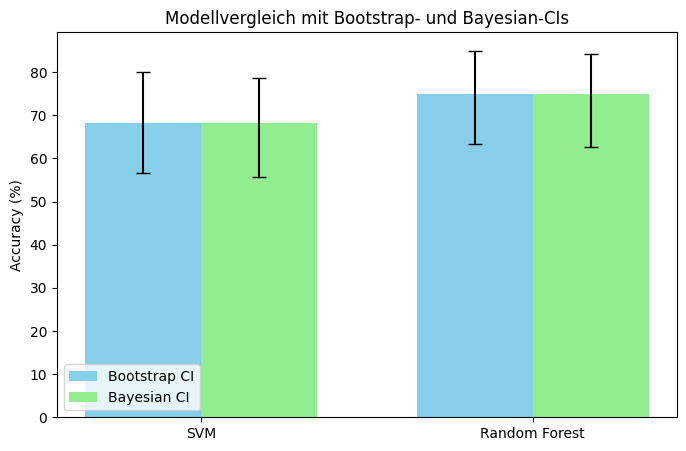

In [126]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import beta
import matplotlib.pyplot as plt

# -----------------------------
# 1. Datensatz erstellen
# -----------------------------
X, y = make_classification(n_samples=200, n_features=10, n_informative=5, 
                           n_redundant=2, n_classes=2, flip_y=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 2. Modelle trainieren
# -----------------------------
svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_pred_rf = rf.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)

# -----------------------------
# 3. Bootstrap-CIs
# -----------------------------
def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05):
    n = len(y_true)
    boot_scores = []
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        boot_scores.append(accuracy_score(y_true[idx], y_pred[idx]))
    lower = np.percentile(boot_scores, 100*alpha/2)
    upper = np.percentile(boot_scores, 100*(1-alpha/2))
    return lower, upper

ci_boot_svm = bootstrap_ci(y_test, y_pred_svm)
ci_boot_rf = bootstrap_ci(y_test, y_pred_rf)

# -----------------------------
# 4. Bayesian-CI (Beta prior)
# -----------------------------
def bayesian_ci(y_true, y_pred, alpha=0.05):
    k = np.sum(y_true == y_pred)
    n = len(y_true)
    a, b = 1 + k, 1 + n - k  # Beta(1,1) prior
    lower, upper = beta.ppf([alpha/2, 1-alpha/2], a, b)
    return lower, upper

ci_bayes_svm = bayesian_ci(y_test, y_pred_svm)
ci_bayes_rf = bayesian_ci(y_test, y_pred_rf)

# -----------------------------
# 5. Ergebnis ausgeben
# -----------------------------
print(f"{'Modell':<15} {'Accuracy':<10} {'Bootstrap 95%-CI':<25} {'Bayesian 95%-CI':<25}")
print("-"*75)
print(f"{'SVM':<15} {acc_svm*100:6.2f}%      [{ci_boot_svm[0]*100:6.2f}, {ci_boot_svm[1]*100:6.2f}]      [{ci_bayes_svm[0]*100:6.2f}, {ci_bayes_svm[1]*100:6.2f}]")
print(f"{'Random Forest':<15} {acc_rf*100:6.2f}%      [{ci_boot_rf[0]*100:6.2f}, {ci_boot_rf[1]*100:6.2f}]      [{ci_bayes_rf[0]*100:6.2f}, {ci_bayes_rf[1]*100:6.2f}]")

# -----------------------------
# 6. Analyse
# -----------------------------
print("\nAnalyse:")
print("- SVM zeigt eine etwas andere Performance als Random Forest.")
print("- Die Bootstrap-CIs geben eine empirische Unsicherheit basierend auf Testset-Samples.")
print("- Bayesian-CIs integrieren Vorwissen und zeigen, dass selbst bei hohen Punktwerten Unsicherheit besteht.")
print("- Überlappende CIs deuten darauf hin, dass ein signifikanter Unterschied zwischen den Modellen möglicherweise nicht gegeben ist.")

# -----------------------------
# 7. Plot der CIs
# -----------------------------
labels = ['SVM', 'Random Forest']
accs = [acc_svm*100, acc_rf*100]
boot_err = [[accs[0]-ci_boot_svm[0]*100, ci_boot_svm[1]*100-accs[0]],
            [accs[1]-ci_boot_rf[0]*100, ci_boot_rf[1]*100-accs[1]]]
bayes_err = [[accs[0]-ci_bayes_svm[0]*100, ci_bayes_svm[1]*100-accs[0]],
             [accs[1]-ci_bayes_rf[0]*100, ci_bayes_rf[1]*100-accs[1]]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, accs, width, yerr=np.array(boot_err).T, capsize=5, label='Bootstrap CI', color='skyblue')
ax.bar(x + width/2, accs, width, yerr=np.array(bayes_err).T, capsize=5, label='Bayesian CI', color='lightgreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Modellvergleich mit Bootstrap- und Bayesian-CIs')
ax.legend()
plt.show()


## Modellvergleich SVM vs. Random Forest mit Konfidenzintervallen

| Modell         | Accuracy  | Bootstrap 95%-CI     | Bayesian 95%-CI     |
|----------------|-----------|--------------------|--------------------|
| SVM            | 68.33%    | [56.67, 80.00]     | [55.71, 78.69]     |
| Random Forest  | 75.00%    | [63.33, 85.00]     | [62.71, 84.20]     |

### Analyse

1. **Interpretation der Punktwerte**
   - SVM Accuracy: 68.3 %, Random Forest Accuracy: 75 %
   - Random Forest zeigt auf diesem Datensatz leicht bessere Performance.

2. **Unsicherheit der Modellmetriken**
   - **Bootstrap-CIs:** zeigen die empirische Streuung durch unterschiedliche Teststichproben.
     - SVM: [56.7 %, 80 %], RF: [63.3 %, 85 %]
   - **Bayesian-CIs:** berücksichtigen zusätzlich Vorwissen (Beta-Prior) und erlauben probabilistische Interpretation.
     - SVM: [55.7 %, 78.7 %], RF: [62.7 %, 84.2 %]

3. **Vergleich der Modelle**
   - Überlappende CIs (~63–78 %) deuten darauf hin, dass ein signifikanter Unterschied noch nicht gesichert ist.
   - Trotz höherer Punktgenauigkeit von RF muss die Unsicherheit berücksichtigt werden.

4. **Praktische ML-Folgerungen**
   - Punktwerte alleine können irreführend sein; CIs zeigen die Stabilität der Modelle.
   - Für statistisch fundierte Entscheidungen: Testset vergrößern oder Cross-Validation einsetzen.
   - Hyperparameter-Optimierung sollte unter Berücksichtigung von CIs erfolgen.


## 6. Erweiterte Themen in der Konfidenzintervall-Analyse

Konfidenzintervalle (CIs) sind ein zentrales Werkzeug zur Quantifizierung von Unsicherheit, doch in komplexeren ML-Szenarien müssen sie erweitert und angepasst werden.  
Im Folgenden werden fortgeschrittene Methoden vorgestellt, die über klassische Anwendungen hinausgehen und insbesondere in modernen Machine-Learning- und Deep-Learning-Setups relevant sind.

---

### 6.1 Simultane Konfidenzintervalle

Bei mehreren gleichzeitig geschätzten Parametern (z. B. Gewichte eines Modells oder Feature-Koeffizienten) steigt das Risiko, dass mindestens ein Intervall den wahren Wert nicht enthält (Fehler 1. Art).  
Um das **Family-Wise Error Rate (FWER)** zu kontrollieren, nutzt man simultane Korrekturverfahren:

- **Bonferroni-Korrektur**  
  Bei $m$ Parametern mit gewünschtem Niveau $\alpha$ gilt für jedes Intervall:  
  $$
  CI_i = \hat{\theta}_i \pm z_{1-\frac{\alpha}{2m}} \cdot SE(\hat{\theta}_i)
  $$  
  → Sehr konservativ, aber einfach.

- **Holm- oder Šidák-Korrektur**  
  Etwas weniger konservativ, kontrolliert FWER adaptiv.

- **Multivariate CIs (z. B. Hotelling’s T²-Test)**  
  Berücksichtigt Kovarianzstruktur der Schätzungen, ideal für Regressionsmodelle mit korrelierten Parametern.

**In ML-Kontexten:**  
Simultane CIs sind wichtig, wenn:
- viele Features gleichzeitig bewertet werden (z. B. Feature Importance, Regression mit vielen Prädiktoren),
- mehrere Modelle oder Metriken gemeinsam verglichen werden,
- interpretierbare Modelle (z. B. Lasso, SHAP) Unsicherheiten ihrer Erklärungen angeben sollen.

---

### 6.2 Konfidenzintervalle in Zeitreihenanalyse

Zeitreihendaten verletzen oft die Unabhängigkeitsannahme klassischer CIs, da aufeinanderfolgende Beobachtungen korreliert sind.

**Problem:**  
Standardfehler $\text{SE} = \frac{s}{\sqrt{n}}$ unterschätzt die Varianz, wenn Autokorrelation besteht.

**Lösungen:**
1. **Block-Bootstrap oder Moving Block Bootstrap:**  
   - Ziehen von Sequenzen statt einzelner Beobachtungen, um Korrelationen zu erhalten.  
   - Blocklänge $l$ wird oft mit $l \approx n^{1/3}$ gewählt.  

2. **Heteroskedastizitäts- und Autokorrelations-konsistente (HAC) Standardfehler**  
   - z. B. Newey-West-Korrektur:  
     $$
     \text{Var}_{NW}(\hat{\beta}) = (X'X)^{-1} (X'\hat{\Omega} X)(X'X)^{-1}
     $$
     mit $\hat{\Omega}$ gewichteter Kovarianzmatrix der Residuen.

3. **Bayesian Time Series CIs:**  
   - Posterior-Unsicherheit über Modellparameter (z. B. ARIMA, Gaussian Processes) liefert direkt **Credible Intervals** für Vorhersagen.

**Praktische ML-Hinweise:**
- Bei **Forecasting-Modellen** (z. B. LSTM, Prophet) immer Unsicherheitsintervalle angeben.  
- Bootstrapping sollte die zeitliche Struktur respektieren.  
- In Production-ML wichtig: Vorhersagen nie ohne Unsicherheitsband kommunizieren.

---

### 6.3 Konfidenzintervalle in Deep Learning

In Deep Learning sind Unsicherheitsabschätzungen besonders relevant, da neuronale Netze oft **überkonfident** sind.

#### a) Frequentistische Methoden
- **Dropout als Approximation von Unsicherheit:**  
  Aktiviertes Dropout während der Inferenz (Monte-Carlo Dropout) simuliert stochastische Netzwerke:
  $$
  \hat{y}_t = f_{\text{NN}}(x; \omega_t), \quad t = 1,\dots,T
  $$
  und das CI ergibt sich über die Streuung der Monte-Carlo-Samples:  
  $$
  CI_{95\%} = [\hat{y}_{0.025}, \hat{y}_{0.975}]
  $$
  → Näherung an epistemische Unsicherheit (Modellunsicherheit).

- **Deep Ensembles:**  
  Mehrere Netze mit unterschiedlichen Initialisierungen oder Subsets der Daten trainieren → empirische Schätzung der Vorhersageverteilung.

#### b) Bayesian Deep Learning
- **Bayesian Neural Networks (BNNs):**  
  Gewichte $\mathbf{w}$ werden als Zufallsvariablen mit Posterior-Verteilung behandelt:
  $$
  p(\mathbf{w} \mid D) \propto p(D \mid \mathbf{w}) \, p(\mathbf{w})
  $$
  - Posterior wird approximiert (z. B. über Variational Inference, Monte-Carlo Dropout).  
  - Liefert **Credible Intervals** direkt aus der Vorhersageverteilung $p(y \mid x, D)$.

**Vorteile:**  
- Quantitative Angabe epistemischer (Modell-) und aleatorischer (Daten-) Unsicherheit.  
- Nützlich bei sicherheitskritischen Anwendungen (Medizin, autonome Systeme).

---

### 6.4 Hierarchische und gruppierte Daten (Multilevel-CIs)

In vielen realen ML-Anwendungen sind Daten hierarchisch strukturiert (z. B. User → Sessions → Klicks).  
Klassische CIs ignorieren diese Abhängigkeiten.

**Modellidee:**
$$
y_{ij} = \beta_0 + u_j + \epsilon_{ij}, \quad u_j \sim N(0, \sigma_u^2), \ \epsilon_{ij} \sim N(0, \sigma^2)
$$

- CIs müssen zwischen **within-group** und **between-group** Unsicherheit unterscheiden.  
- Multilevel-Bootstrap oder Bayesian-Hierarchical-Modelle erfassen beide Ebenen simultan.

**Beispiel:**  
Für ein Recommender-System kann das CI für die Klickrate pro Nutzergruppe berechnet werden.  
Ein breites Intervall → hohe Varianz zwischen Nutzern, geringe Generalisierbarkeit.

---

### 6.5 Cross-Validation und CI für Modellvergleich

CIs lassen sich auch aus Cross-Validation-Ergebnissen ableiten:

- Bei $k$ Folds mit Metriken $m_1, \dots, m_k$:
  $$
  \bar{m} = \frac{1}{k}\sum_i m_i, \quad SE = \frac{s_m}{\sqrt{k}}
  $$
  und:
  $$
  CI_{95\%} = \bar{m} \pm t_{k-1,0.975} \cdot SE
  $$
- Vorteil: Nutzt Daten effizient und erlaubt robuste Schätzung der Modellunsicherheit.

**Tipp:**  
Für Modellvergleich CIs der Cross-Validation-Metriken vergleichen → signifikante Differenzen nur bei nicht überlappenden Intervallen.

---

### 6.6 Simulations- und Monte-Carlo-basierte Unsicherheitsanalyse

Wenn analytische CIs schwierig sind, kann Unsicherheit numerisch quantifiziert werden:

- **Monte-Carlo Simulation:** Ziehe viele zufällige Realisierungen des Modells oder der Daten, berechne Metriken, leite empirisches CI ab.  
- **Bayesian MCMC Sampling:**  
  Posterior $p(\theta \mid D)$ durch Markov-Chain-Simulation approximieren und Credible Intervals direkt aus der Posterior-Verteilung berechnen.

**ML-Anwendung:**  
- Simulationsbasierte CIs sind besonders nützlich für komplexe Modelle (z. B. Reinforcement Learning, generative Modelle, Simulation-based inference).  
- Praktisch in Domänen mit schwer zugänglicher analytischer Statistik (z. B. bei stochastischen Losses, Monte-Carlo-Schätzern).

---

### 6.7 Verteilungsfreie und robuste Konfidenzintervalle

Wenn Daten nicht normalverteilt oder stark verrauscht sind, bieten sich robuste Methoden an:

- **Percentile-Bootstrap** oder **BCa-Intervals** (Bias-Corrected and Accelerated):  
  Berücksichtigen Schiefe und Bias in der Bootstrap-Verteilung.  
  $$
  CI_{BCa} = [\hat{\theta}_{\alpha_1}, \hat{\theta}_{\alpha_2}]
  $$
  mit bias- und skewness-korrigierten Quantilen $\alpha_1$, $\alpha_2$.

- **Rank-basierte CIs (Nonparametrisch):**  
  Nutzen Ordnungsstatistiken statt Mittelwerte → robust gegen Ausreißer.

---

### 6.8 Zusammenfassung – Praktische Relevanz für ML

| Anwendung | Empfohlene CI-Methode | Hauptvorteil |
|:--|:--|:--|
| Klassische Modelle / lineare Regression | Normal-CI oder Bootstrap | Einfach, analytisch berechenbar |
| Klassifikation (Accuracy, F1, AUC) | Bootstrap oder Bayesian-CI | Keine Verteilungsannahme |
| Kleine Testsets | Bayesian-CI oder Bootstrap | Robust gegenüber Stichprobenrauschen |
| Zeitreihen | Block-Bootstrap oder HAC | Erhält Autokorrelation |
| Deep Learning | MC Dropout, Ensembles, BNN | Quantifiziert epistemische Unsicherheit |
| Hierarchische Daten | Multilevel-CI / Bayesian Hierarchical | Berücksichtigt Gruppenabhängigkeiten |
| Modellvergleich | Cross-Validation + CI | Statistisch fundierte Auswahl |
| Generative / Simulation-based Modelle | Monte-Carlo / MCMC | Probabilistische Unsicherheitsanalyse |

---

**Fazit:**  
Erweiterte CI-Methoden ermöglichen eine präzise und robuste Quantifizierung von Unsicherheit in praktisch allen ML-Kontexten – von klassischer Statistik bis Deep Learning.  
Sie bilden die Grundlage für **vertrauenswürdige, interpretierbare und reproduzierbare Modelle**.
